In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
with open("GB_category_id.json", "r") as f:
    categorias = json.load(f)

In [3]:
numericas = [
    "views",
    "likes",
    "dislikes",
    "comment_count"
]

In [4]:
df = pd.read_csv("GBvideos_cc50_202101.csv")

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...,Devon,50.700405,-3.529950,POINT (-3.529950197 50.70040529)
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...,Manchester,53.500415,-2.247987,POINT (-2.247987103 53.50041526)
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...,Bath And North East Somerset,51.383749,-2.350022,POINT (-2.350022218 51.3837486)
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...,Aberdeen,57.170398,-2.079987,POINT (-2.079987021 57.17039797)
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...,Southampton,50.900031,-1.399977,POINT (-1.399976849 50.90003135)


In [5]:
df.info()

df.describe()

df.columns

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38916 entries, 0 to 38915
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                38916 non-null  object 
 1   trending_date           38916 non-null  object 
 2   title                   38916 non-null  object 
 3   channel_title           38916 non-null  object 
 4   category_id             38916 non-null  int64  
 5   publish_time            38916 non-null  object 
 6   tags                    38916 non-null  object 
 7   views                   38916 non-null  int64  
 8   likes                   38916 non-null  int64  
 9   dislikes                38916 non-null  int64  
 10  comment_count           38916 non-null  int64  
 11  thumbnail_link          38916 non-null  object 
 12  comments_disabled       38916 non-null  bool   
 13  ratings_disabled        38916 non-null  bool   
 14  video_error_or_removed  38916 non-null

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [6]:
df.describe()

,category_id,views,likes,dislikes,comment_count,lat,lon
count,38916.000000,3.891600e+04,3.891600e+04,3.891600e+04,3.891600e+04,38916.000000,38916.000000
mean,16.827937,5.911944e+06,1.345196e+05,7.612560e+03,1.308835e+04,53.383720,-2.379078
std,7.752728,1.900121e+07,3.499893e+05,5.095683e+04,5.066740e+04,2.043531,2.103878
min,1.000000,8.510000e+02,0.000000e+00,0.000000e+00,0.000000e+00,50.133722,-7.333284
25%,10.000000,2.515272e+05,5.897000e+03,2.000000e+02,6.790000e+02,51.499995,-3.529950
50%,20.000000,9.818890e+05,2.518250e+04,8.210000e+02,2.478000e+03,53.200020,-2.180007
75%,24.000000,3.683628e+06,1.140892e+05,3.357500e+03,9.241500e+03,54.879995,-1.080022
max,43.000000,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06,58.966981,1.300013


In [7]:
df.nunique()

,0
video_id,3272
trending_date,205
title,3369
channel_title,1625
category_id,16
publish_time,3250
tags,3122
views,38393
likes,30556
dislikes,11092


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
diccionario = {}

for item in categorias["items"]:
    diccionario[int(item["id"])] = item["snippet"]["title"]

diccionario

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [10]:
df["category_name"] = df["category_id"].map(diccionario)

df[["category_id", "category_name"]].head()

,category_id,category_name
0,26,Howto & Style
1,24,Entertainment
2,10,Music
3,17,Sports
4,25,News & Politics


In [11]:
df["category_name"] = df["category_name"].fillna("No clasificada")

In [12]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


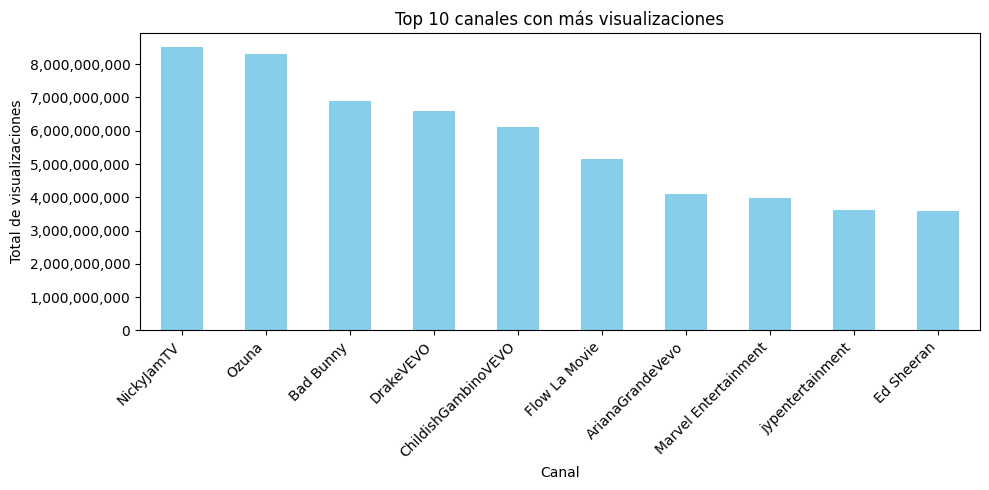

In [13]:
from matplotlib.ticker import FuncFormatter

canales = (
    df.groupby("channel_title")["views"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

canales.plot(kind="bar", color="skyblue")

plt.title("Top 10 canales con más visualizaciones")
plt.xlabel("Canal")
plt.ylabel("Total de visualizaciones")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()
plt.show()

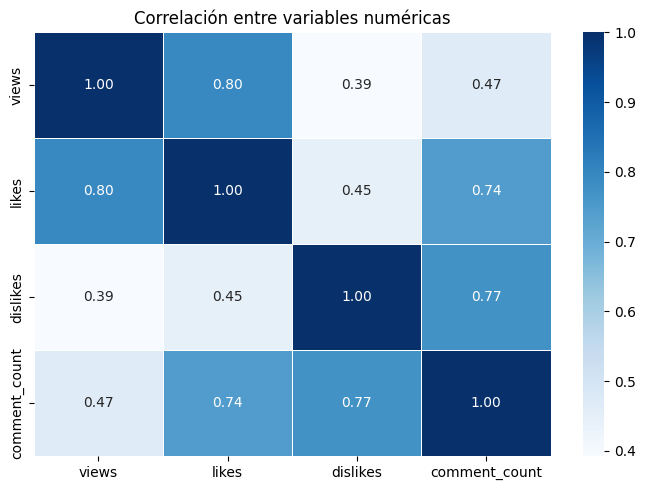

In [14]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación entre variables numéricas")

plt.tight_layout()
plt.show()

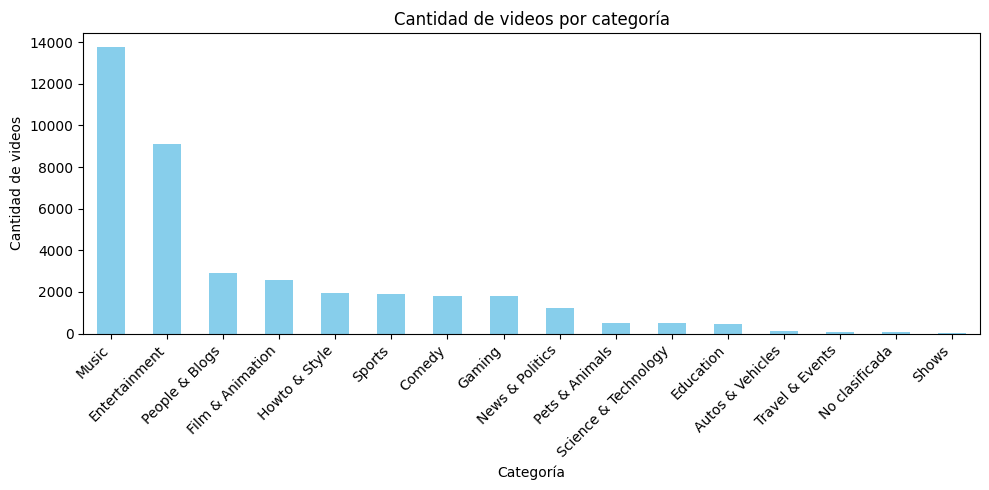

In [15]:
categoria = (
    df["category_name"]
      .value_counts()
)

plt.figure(figsize=(10,5))

categoria.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Cantidad de videos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de videos")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

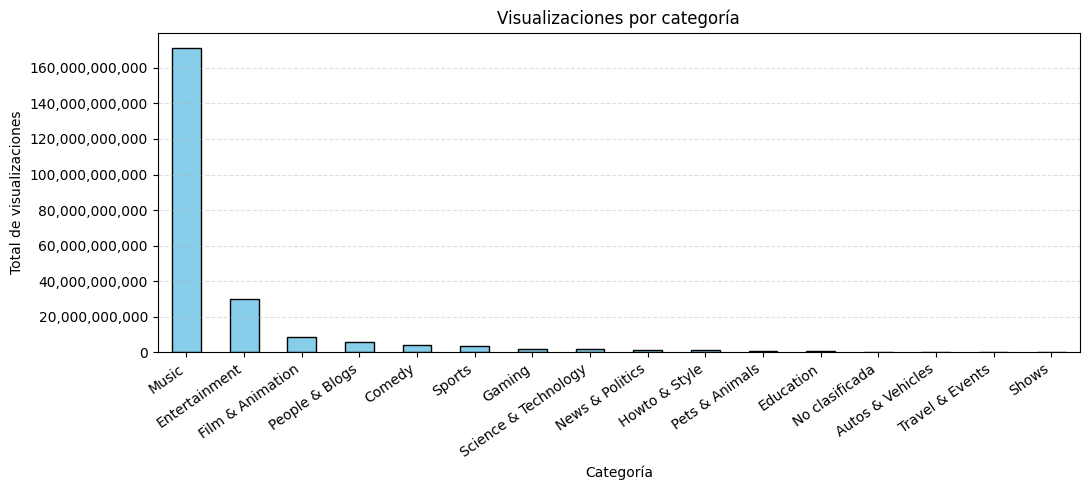

In [16]:
categoria_views = (
    df.groupby("category_name")["views"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,5))

categoria_views.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Visualizaciones por categoría")
plt.xlabel("Categoría")
plt.ylabel("Total de visualizaciones")

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

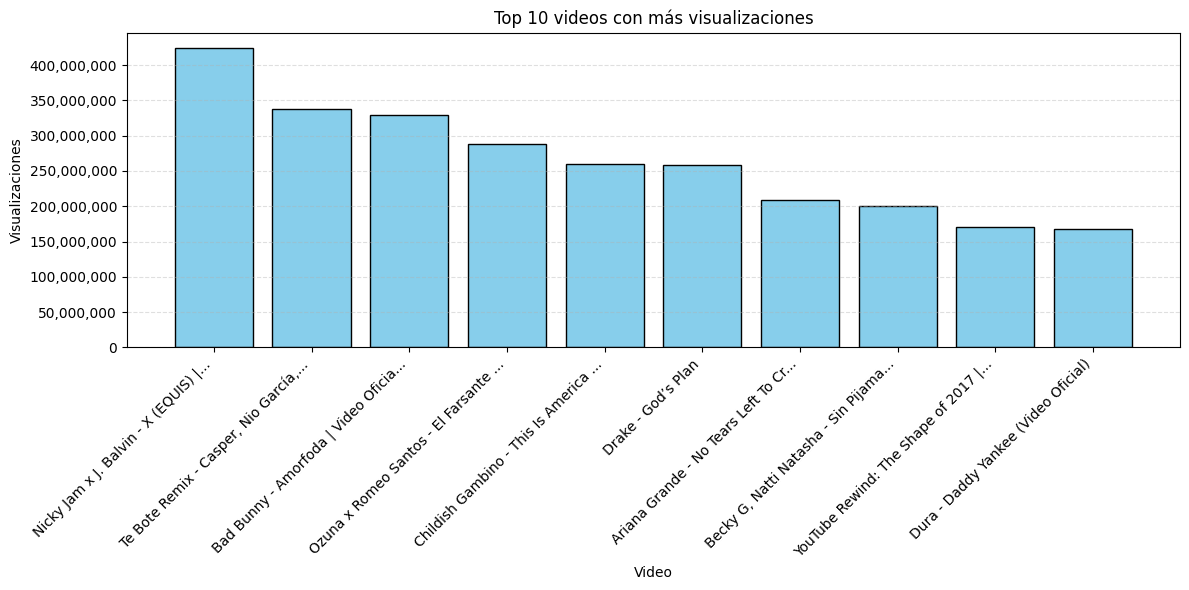

In [17]:
top_videos = (
    df.sort_values("views", ascending=False)
      .drop_duplicates(subset="title")
      .head(10)
)

titulos = [
    titulo[:35] + "..."
    if len(titulo) > 35 else titulo
    for titulo in top_videos["title"]
]

plt.figure(figsize=(12,6))

plt.bar(
    titulos,
    top_videos["views"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 videos con más visualizaciones")
plt.xlabel("Video")
plt.ylabel("Visualizaciones")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

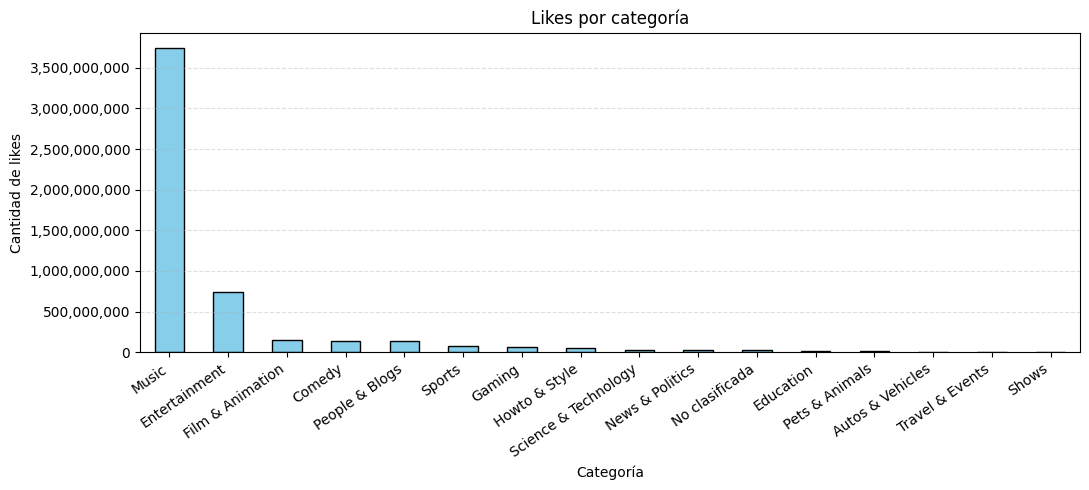

In [18]:
likes_categoria = (
    df.groupby("category_name")["likes"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,5))

likes_categoria.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Likes por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de likes")

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

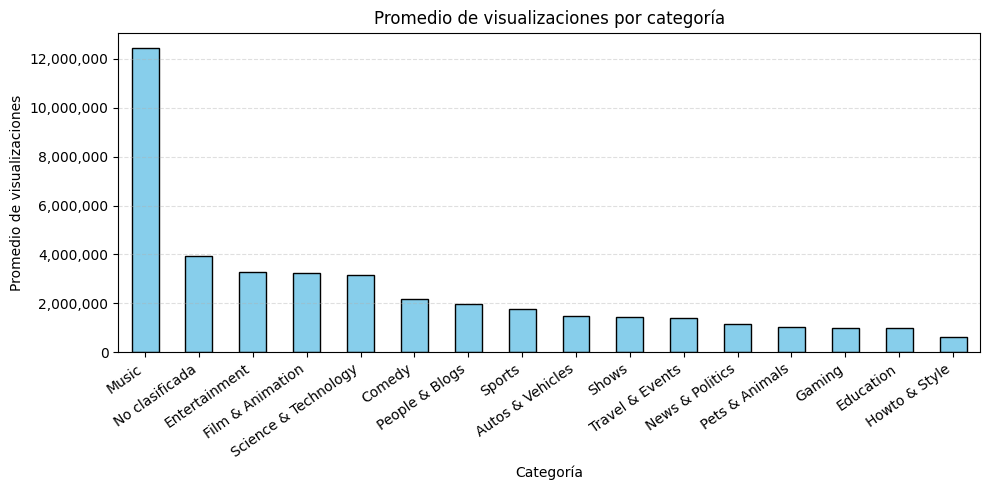

In [19]:
promedio = (
    df.groupby("category_name")["views"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

promedio.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Promedio de visualizaciones por categoría")
plt.xlabel("Categoría")
plt.ylabel("Promedio de visualizaciones")

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

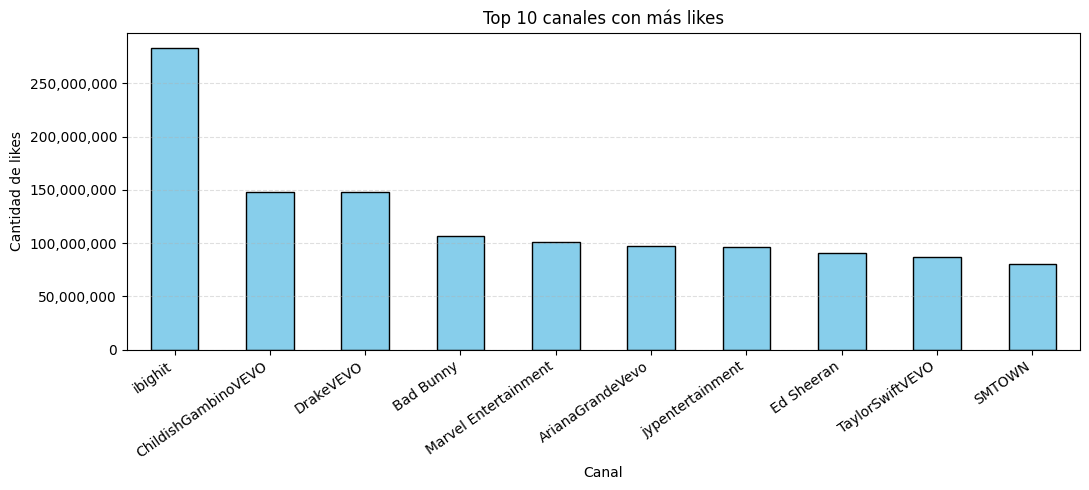

In [20]:
likes_canales = (
    df.groupby("channel_title")["likes"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(11,5))

likes_canales.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 canales con más likes")
plt.xlabel("Canal")
plt.ylabel("Cantidad de likes")

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

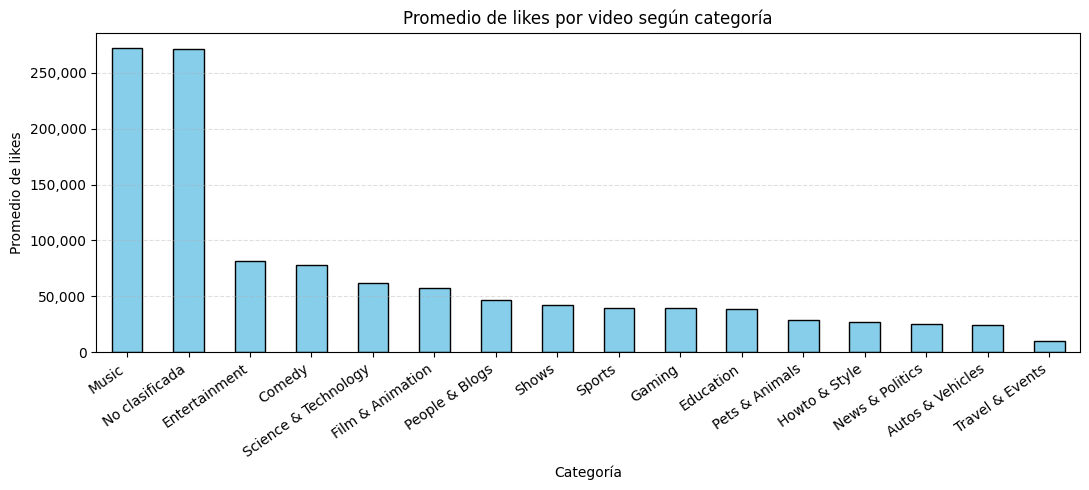

In [21]:
promedio_likes = (
    df.groupby("category_name")["likes"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11,5))

promedio_likes.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Promedio de likes por video según categoría")
plt.xlabel("Categoría")
plt.ylabel("Promedio de likes")

plt.xticks(rotation=35, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [22]:
df["ratio_likes"] = df["likes"] / (df["dislikes"] + 1)

In [23]:
df[["likes", "dislikes", "ratio_likes"]].head()

,likes,dislikes,ratio_likes
0,55681,10247,5.433353
1,25561,2294,11.137691
2,787420,43420,18.134543
3,193,12,14.846154
4,30,2,10.000000


In [24]:
df["ratio_likes"].describe()

,ratio_likes
count,38916.000000
mean,82.919643
std,1819.229513
min,0.000000
25%,15.183553
50%,30.904377
75%,59.245411
max,123856.000000


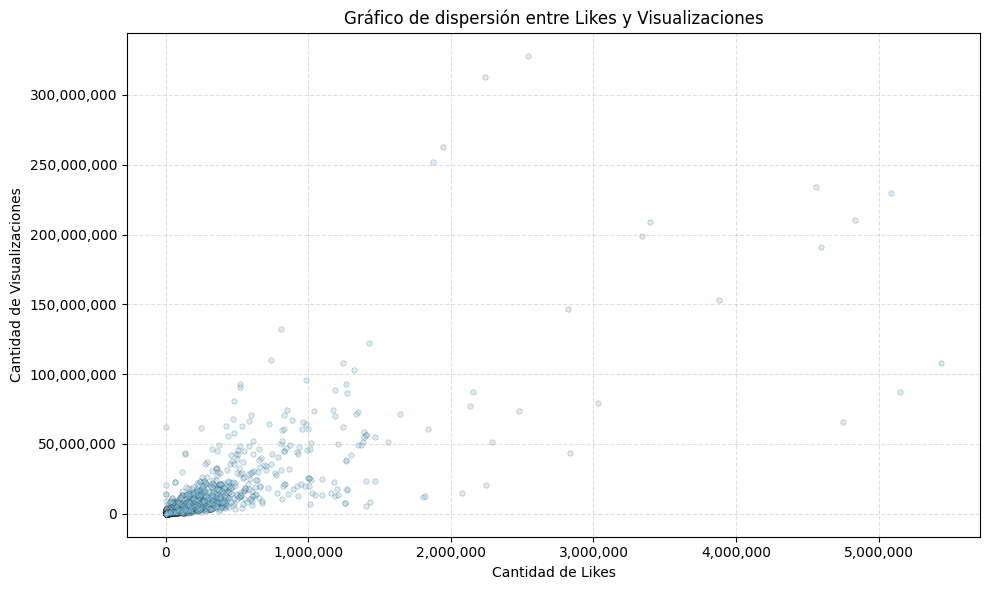

In [33]:
muestra = df.sample(3000, random_state=42)

plt.figure(figsize=(10,6))

plt.scatter(
    muestra["likes"],
    muestra["views"],
    color="skyblue",
    edgecolors="black",
    linewidths=0.3,
    alpha=0.35,
    s=15
)

plt.title("Gráfico de dispersión entre Likes y Visualizaciones")
plt.xlabel("Cantidad de Likes")
plt.ylabel("Cantidad de Visualizaciones")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{int(y):,}")
)

plt.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()